# Import Library

In [92]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 11

# Load Dataset

In [93]:
path = r"C:\kuliah\tubes STD & Algo\Churn_Modelling.csv"

df = pd.read_csv(path)

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Data Checking

In [94]:

print("SHAPE DATASET")
print(df.shape)

print("\n")

print("INFO DATASET")
print(df.info())

print("\n")

print("TIPE DATA")
print(df.dtypes)

SHAPE DATASET
(10000, 14)


INFO DATASET
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB
None


TIPE DATA
RowNumber            int64
CustomerId           int

In [95]:
missing = pd.DataFrame({
    "Missing Value": df.isnull().sum(),
    "Persentase (%)": round(df.isnull().mean()*100,2)
})

display(missing)

,Missing Value,Persentase (%)
RowNumber,0,0.0
CustomerId,0,0.0
Surname,0,0.0
CreditScore,0,0.0
Geography,0,0.0
Gender,0,0.0
Age,0,0.0
Tenure,0,0.0
Balance,0,0.0
NumOfProducts,0,0.0


In [96]:
duplicate_rows = df.duplicated()
jumlah_duplikat = duplicate_rows.sum()
persentase_duplikat = (jumlah_duplikat / len(df)) * 100

print("Jumlah baris duplikat:", jumlah_duplikat)
print("Persentase duplikat:", round(persentase_duplikat, 2), "%")

Jumlah baris duplikat: 0
Persentase duplikat: 0.0 %


In [97]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


# Rekayasa fitur

In [98]:
df["Churn_Label"] = df["Exited"].map({
    0:"Non-Churn",
    1:"Churn"
})

# Churn Rate per Negara
country_rate = (
    df.groupby("Geography")["Exited"]
      .mean()
      .reset_index()
)

country_rate.columns = [
    "Geography",
    "Country_Churn_Rate"
]

df = df.merge(country_rate,on="Geography")

# Non Churn Rate
df["Country_NonChurn_Rate"] = 1 - df["Country_Churn_Rate"]


gender_rate = (
    df.groupby("Gender")["Exited"]
      .mean()
      .reset_index()
)

gender_rate.columns = [
    "Gender",
    "Gender_Churn_Rate"
]

df = df.merge(gender_rate,on="Gender")

# Active Member Churn Rate
active_rate = (
    df.groupby("IsActiveMember")["Exited"]
      .mean()
      .reset_index()
)

active_rate.columns = [
    "IsActiveMember",
    "Active_Churn_Rate"
]

df = df.merge(active_rate,on="IsActiveMember")

# Credit Card Churn Rate
card_rate = (
    df.groupby("HasCrCard")["Exited"]
      .mean()
      .reset_index()
)

card_rate.columns = [
    "HasCrCard",
    "Card_Churn_Rate"
]

df = df.merge(card_rate,on="HasCrCard")

# Product Churn Rate
product_rate = (
    df.groupby("NumOfProducts")["Exited"]
      .mean()
      .reset_index()
)

product_rate.columns = [
    "NumOfProducts",
    "Product_Churn_Rate"
]

df = df.merge(product_rate,on="NumOfProducts")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,...,IsActiveMember,EstimatedSalary,Exited,Churn_Label,Country_Churn_Rate,Country_NonChurn_Rate,Gender_Churn_Rate,Active_Churn_Rate,Card_Churn_Rate,Product_Churn_Rate
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,...,1,101348.88,1,Churn,0.161548,0.838452,0.250715,0.142691,0.201843,0.277144
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,...,1,112542.58,0,Non-Churn,0.166734,0.833266,0.250715,0.142691,0.208149,0.277144
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,...,0,113931.57,1,Churn,0.161548,0.838452,0.250715,0.268509,0.201843,0.827068
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,...,0,93826.63,0,Non-Churn,0.161548,0.838452,0.250715,0.268509,0.208149,0.075817
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,...,1,79084.10,0,Non-Churn,0.166734,0.833266,0.250715,0.142691,0.201843,0.277144


In [99]:
df["Churn_Label"] = df["Exited"].map({
    0: "Non-Churn",
    1: "Churn"
})

In [100]:
total_customer = len(df)

total_churn = df["Exited"].sum()
total_nonchurn = total_customer - total_churn

overall_churn_rate = total_churn / total_customer
overall_nonchurn_rate = total_nonchurn / total_customer

print(f"Total Customer     : {total_customer}")
print(f"Total Churn        : {total_churn}")
print(f"Total Non-Churn    : {total_nonchurn}")
print(f"Churn Rate         : {overall_churn_rate:.2%}")
print(f"Non-Churn Rate     : {overall_nonchurn_rate:.2%}")

Total Customer     : 10000
Total Churn        : 2037
Total Non-Churn    : 7963
Churn Rate         : 20.37%
Non-Churn Rate     : 79.63%


In [101]:
country_summary = (
    df.groupby("Geography")
      .agg(
          Total_Customer=("Exited","count"),
          Total_Churn=("Exited","sum")
      )
      .reset_index()
)

country_summary["Total_NonChurn"] = (
    country_summary["Total_Customer"] -
    country_summary["Total_Churn"]
)

country_summary["Churn_Rate"] = (
    country_summary["Total_Churn"] /
    country_summary["Total_Customer"]
)

country_summary["NonChurn_Rate"] = (
    country_summary["Total_NonChurn"] /
    country_summary["Total_Customer"]
)


In [102]:
gender_summary = (
    df.groupby("Gender")
      .agg(
          Total_Customer=("Exited","count"),
          Total_Churn=("Exited","sum")
      )
      .reset_index()
)

gender_summary["Total_NonChurn"] = (
    gender_summary["Total_Customer"] -
    gender_summary["Total_Churn"]
)

gender_summary["Churn_Rate"] = (
    gender_summary["Total_Churn"] /
    gender_summary["Total_Customer"]
)

gender_summary["NonChurn_Rate"] = (
    gender_summary["Total_NonChurn"] /
    gender_summary["Total_Customer"]
)


In [103]:
active_summary = (
    df.groupby("IsActiveMember")
      .agg(
          Total_Customer=("Exited","count"),
          Total_Churn=("Exited","sum")
      )
      .reset_index()
)

active_summary["Total_NonChurn"] = (
    active_summary["Total_Customer"] -
    active_summary["Total_Churn"]
)

active_summary["Churn_Rate"] = (
    active_summary["Total_Churn"] /
    active_summary["Total_Customer"]
)

active_summary["NonChurn_Rate"] = (
    active_summary["Total_NonChurn"] /
    active_summary["Total_Customer"]
)


In [104]:
card_summary = (
    df.groupby("HasCrCard")
      .agg(
          Total_Customer=("Exited","count"),
          Total_Churn=("Exited","sum")
      )
      .reset_index()
)

card_summary["Total_NonChurn"] = (
    card_summary["Total_Customer"] -
    card_summary["Total_Churn"]
)

card_summary["Churn_Rate"] = (
    card_summary["Total_Churn"] /
    card_summary["Total_Customer"]
)

card_summary["NonChurn_Rate"] = (
    card_summary["Total_NonChurn"] /
    card_summary["Total_Customer"]
)

In [105]:
product_summary = (
    df.groupby("NumOfProducts")
      .agg(
          Total_Customer=("Exited","count"),
          Total_Churn=("Exited","sum")
      )
      .reset_index()
)

product_summary["Total_NonChurn"] = (
    product_summary["Total_Customer"] -
    product_summary["Total_Churn"]
)

product_summary["Churn_Rate"] = (
    product_summary["Total_Churn"] /
    product_summary["Total_Customer"]
)

product_summary["NonChurn_Rate"] = (
    product_summary["Total_NonChurn"] /
    product_summary["Total_Customer"]
)

In [106]:
print("\nCountry Summary")
display(country_summary)

print("\nGender Summary")
display(gender_summary)

print("\nActive Member Summary")
display(active_summary)

print("\nCredit Card Summary")
display(card_summary)

print("\nProduct Summary")
display(product_summary)


Country Summary


,Geography,Total_Customer,Total_Churn,Total_NonChurn,Churn_Rate,NonChurn_Rate
0,France,5014,810,4204,0.161548,0.838452
1,Germany,2509,814,1695,0.324432,0.675568
2,Spain,2477,413,2064,0.166734,0.833266



Gender Summary


,Gender,Total_Customer,Total_Churn,Total_NonChurn,Churn_Rate,NonChurn_Rate
0,Female,4543,1139,3404,0.250715,0.749285
1,Male,5457,898,4559,0.164559,0.835441



Active Member Summary


,IsActiveMember,Total_Customer,Total_Churn,Total_NonChurn,Churn_Rate,NonChurn_Rate
0,0,4849,1302,3547,0.268509,0.731491
1,1,5151,735,4416,0.142691,0.857309



Credit Card Summary


,HasCrCard,Total_Customer,Total_Churn,Total_NonChurn,Churn_Rate,NonChurn_Rate
0,0,2945,613,2332,0.208149,0.791851
1,1,7055,1424,5631,0.201843,0.798157



Product Summary


,NumOfProducts,Total_Customer,Total_Churn,Total_NonChurn,Churn_Rate,NonChurn_Rate
0,1,5084,1409,3675,0.277144,0.722856
1,2,4590,348,4242,0.075817,0.924183
2,3,266,220,46,0.827068,0.172932
3,4,60,60,0,1.000000,0.000000


In [107]:
print("\nCountry Churn Rate Describe")
display(country_summary.describe().T)

print("\nGender Churn Rate Describe")
display(gender_summary.describe().T)

print("\nActive Member Churn Rate Describe")
display(active_summary.describe().T)

print("\nCredit Card Churn Rate Describe")
display(card_summary.describe().T)

print("\nProduct Churn Rate Describe")
display(product_summary.describe().T)


Country Churn Rate Describe


,count,mean,std,min,25%,50%,75%,max
Total_Customer,3.0,3333.333333,1455.587968,2477.000000,2493.000000,2509.000000,3761.500000,5014.000000
Total_Churn,3.0,679.000000,230.371439,413.000000,611.500000,810.000000,812.000000,814.000000
Total_NonChurn,3.0,2654.333333,1354.673515,1695.000000,1879.500000,2064.000000,3134.000000,4204.000000
Churn_Rate,3.0,0.217571,0.092581,0.161548,0.164141,0.166734,0.245583,0.324432
NonChurn_Rate,3.0,0.782429,0.092581,0.675568,0.754417,0.833266,0.835859,0.838452



Gender Churn Rate Describe


,count,mean,std,min,25%,50%,75%,max
Total_Customer,2.0,5000.000000,646.295598,4543.000000,4771.500000,5000.000000,5228.500000,5457.000000
Total_Churn,2.0,1018.500000,170.412734,898.000000,958.250000,1018.500000,1078.750000,1139.000000
Total_NonChurn,2.0,3981.500000,816.708332,3404.000000,3692.750000,3981.500000,4270.250000,4559.000000
Churn_Rate,2.0,0.207637,0.060922,0.164559,0.186098,0.207637,0.229176,0.250715
NonChurn_Rate,2.0,0.792363,0.060922,0.749285,0.770824,0.792363,0.813902,0.835441



Active Member Churn Rate Describe


,count,mean,std,min,25%,50%,75%,max
IsActiveMember,2.0,0.5000,0.707107,0.000000,0.250000,0.5000,0.750000,1.000000
Total_Customer,2.0,5000.0000,213.546248,4849.000000,4924.500000,5000.0000,5075.500000,5151.000000
Total_Churn,2.0,1018.5000,400.929545,735.000000,876.750000,1018.5000,1160.250000,1302.000000
Total_NonChurn,2.0,3981.5000,614.475793,3547.000000,3764.250000,3981.5000,4198.750000,4416.000000
Churn_Rate,2.0,0.2056,0.088967,0.142691,0.174145,0.2056,0.237054,0.268509
NonChurn_Rate,2.0,0.7944,0.088967,0.731491,0.762946,0.7944,0.825855,0.857309



Credit Card Churn Rate Describe


,count,mean,std,min,25%,50%,75%,max
HasCrCard,2.0,0.500000,0.707107,0.000000,0.250000,0.500000,0.750000,1.000000
Total_Customer,2.0,5000.000000,2906.208871,2945.000000,3972.500000,5000.000000,6027.500000,7055.000000
Total_Churn,2.0,1018.500000,573.463600,613.000000,815.750000,1018.500000,1221.250000,1424.000000
Total_NonChurn,2.0,3981.500000,2332.745271,2332.000000,3156.750000,3981.500000,4806.250000,5631.000000
Churn_Rate,2.0,0.204996,0.004460,0.201843,0.203419,0.204996,0.206573,0.208149
NonChurn_Rate,2.0,0.795004,0.004460,0.791851,0.793427,0.795004,0.796581,0.798157



Product Churn Rate Describe


,count,mean,std,min,25%,50%,75%,max
NumOfProducts,4.0,2.500000,1.290994,1.000000,1.750000,2.500000,3.250000,4.000000
Total_Customer,4.0,2500.000000,2707.367233,60.000000,214.500000,2428.000000,4713.500000,5084.000000
Total_Churn,4.0,509.250000,611.294460,60.000000,180.000000,284.000000,613.250000,1409.000000
Total_NonChurn,4.0,1990.750000,2283.999617,0.000000,34.500000,1860.500000,3816.750000,4242.000000
Churn_Rate,4.0,0.545007,0.439115,0.075817,0.226812,0.552106,0.870301,1.000000
NonChurn_Rate,4.0,0.454993,0.439115,0.000000,0.129699,0.447894,0.773188,0.924183


# Visualisasi EDA

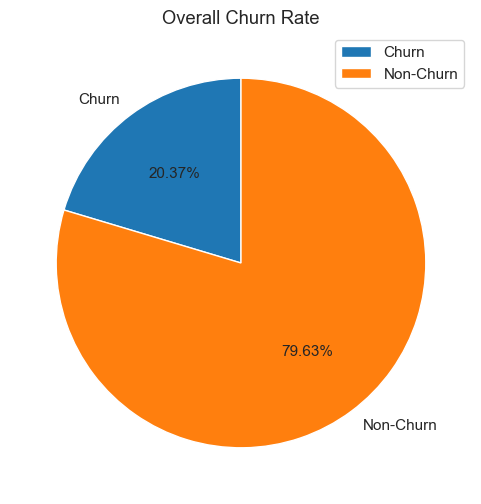

In [108]:
plt.figure(figsize=(6,6))

plt.pie(
    [total_churn, total_nonchurn],
    labels=["Churn", "Non-Churn"],
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Overall Churn Rate")
plt.legend(loc="best")

plt.show()

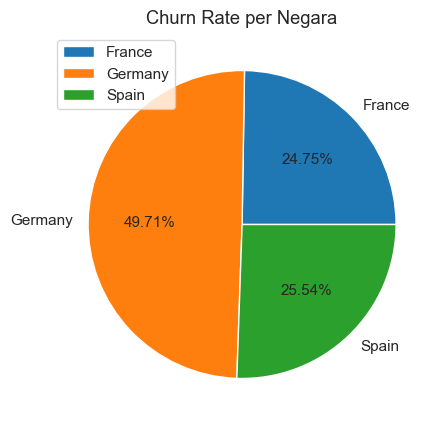

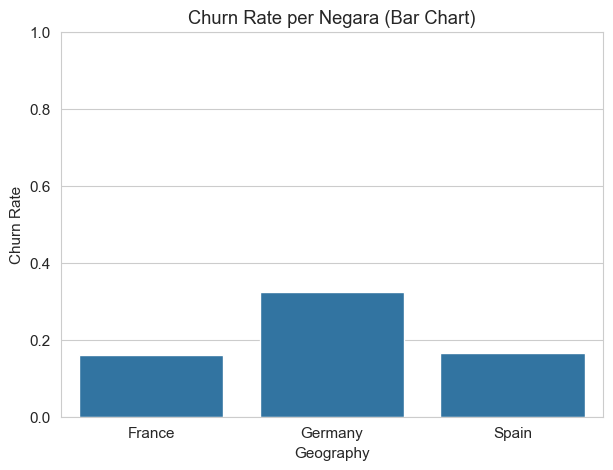

In [124]:
plt.figure(figsize=(7,5))

plt.pie(
    country_summary["Churn_Rate"],
    labels=country_summary["Geography"],
    autopct="%1.2f%%"
)

plt.title("Churn Rate per Negara")
plt.legend(loc="best")

plt.show()

plt.figure(figsize=(7,5))

sns.barplot(
    data=country_summary,
    x="Geography",
    y="Churn_Rate"
)

plt.ylabel("Churn Rate")
plt.title("Churn Rate per Negara (Bar Chart)")
plt.ylim(0,1)

plt.show()

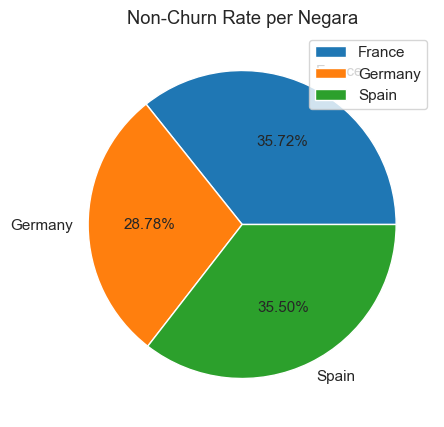

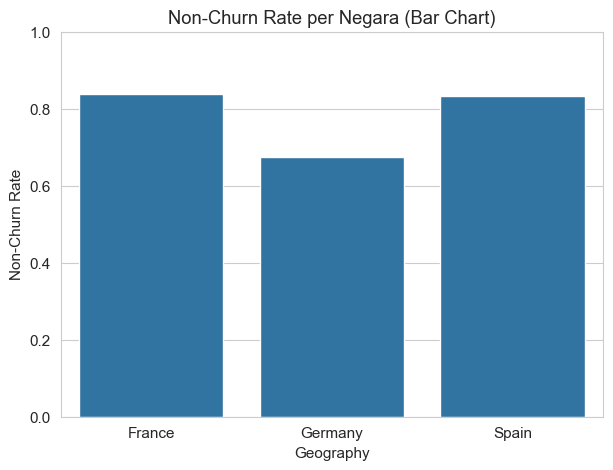

In [111]:
plt.figure(figsize=(7,5))

plt.pie(
    country_summary["NonChurn_Rate"],
    labels=country_summary["Geography"],
    autopct="%1.2f%%"
)

plt.title("Non-Churn Rate per Negara")
plt.legend(loc="best")

plt.show()

plt.figure(figsize=(7,5))

sns.barplot(
    data=country_summary,
    x="Geography",
    y="NonChurn_Rate"
)

plt.ylabel("Non-Churn Rate")
plt.title("Non-Churn Rate per Negara (Bar Chart)")
plt.ylim(0,1)

plt.show()

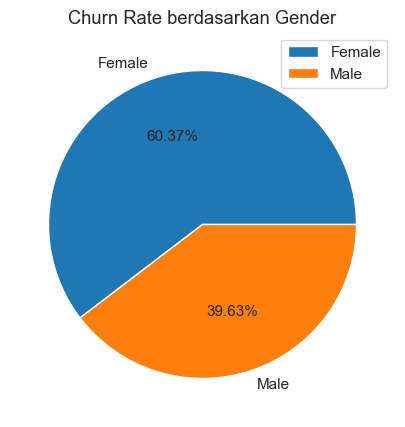

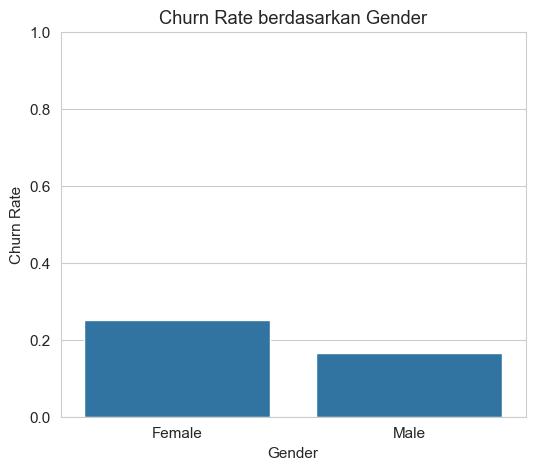

In [125]:
plt.figure(figsize=(6,5))

plt.pie(
    gender_summary["Churn_Rate"],
    labels=gender_summary["Gender"],
    autopct="%1.2f%%"
)

plt.title("Churn Rate berdasarkan Gender")
plt.legend(loc="best")

plt.show()

plt.figure(figsize=(6,5))

sns.barplot(
    data=gender_summary,
    x="Gender",
    y="Churn_Rate"
)

plt.ylabel("Churn Rate")
plt.title("Churn Rate berdasarkan Gender")
plt.ylim(0,1)

plt.show()

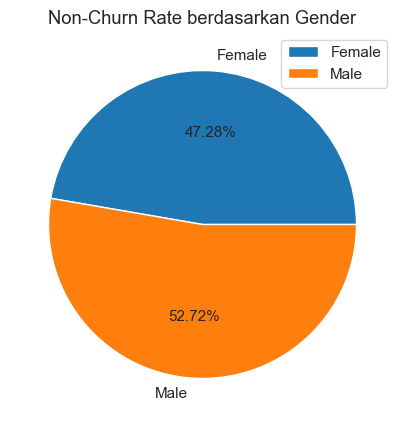

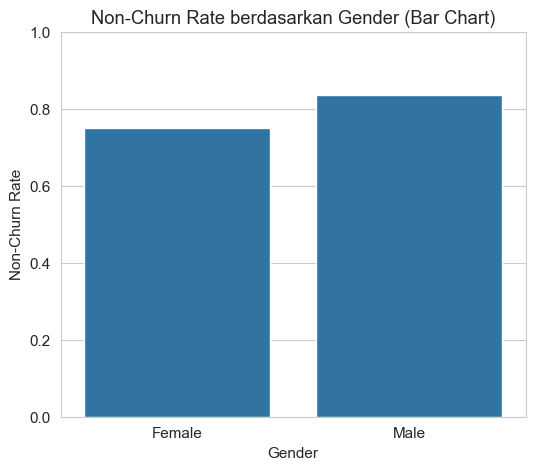

In [113]:
plt.figure(figsize=(6,5))

plt.pie(
    gender_summary["NonChurn_Rate"],
    labels=gender_summary["Gender"],
    autopct="%1.2f%%"
)

plt.title("Non-Churn Rate berdasarkan Gender")
plt.legend(loc="best")

plt.show()

plt.figure(figsize=(6,5))

sns.barplot(
    data=gender_summary,
    x="Gender",
    y="NonChurn_Rate"
)

plt.ylabel("Non-Churn Rate")
plt.title("Non-Churn Rate berdasarkan Gender (Bar Chart)")
plt.ylim(0,1)

plt.show()

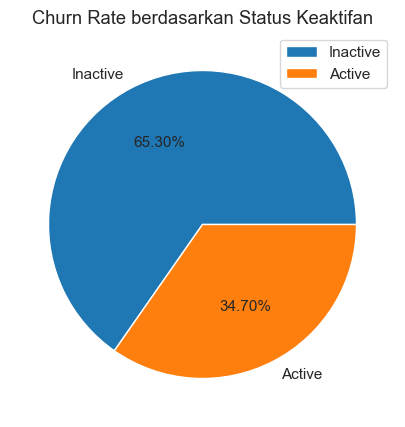

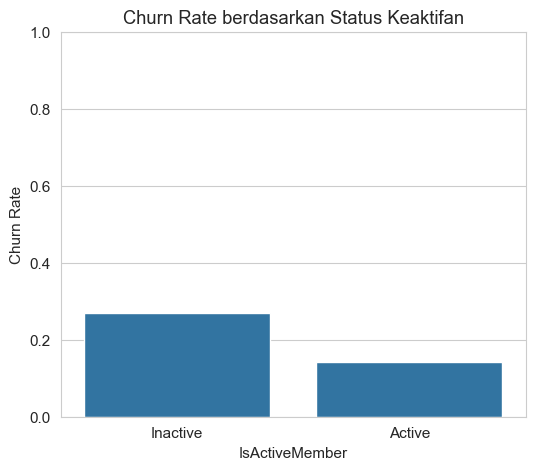

In [114]:
active_plot = active_summary.copy()

active_plot["IsActiveMember"] = active_plot["IsActiveMember"].map({
    0: "Inactive",
    1: "Active"
})

plt.figure(figsize=(6,5))

plt.pie(
    active_plot["Churn_Rate"],
    labels=active_plot["IsActiveMember"],
    autopct="%1.2f%%"
)

plt.title("Churn Rate berdasarkan Status Keaktifan")
plt.legend(loc="best")

plt.show()

plt.figure(figsize=(6,5))

sns.barplot(
    data=active_plot,
    x="IsActiveMember",
    y="Churn_Rate"
)

plt.ylabel("Churn Rate")
plt.title("Churn Rate berdasarkan Status Keaktifan")
plt.ylim(0,1)

plt.show()

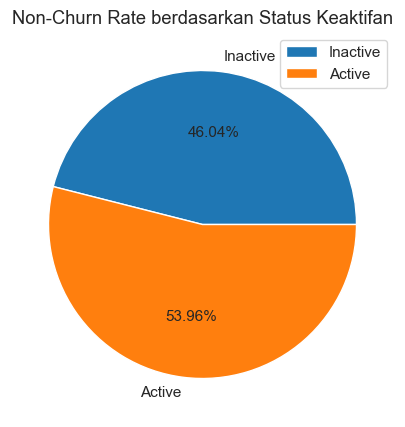

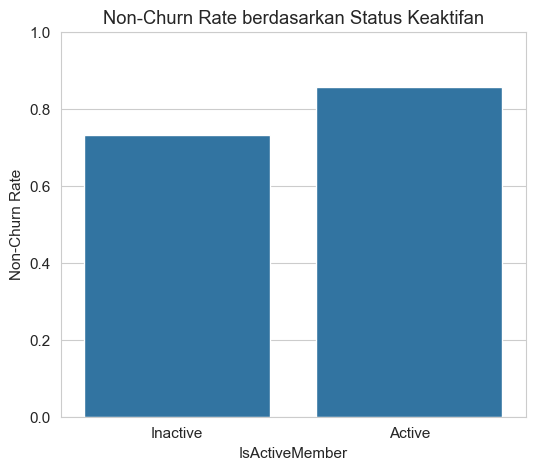

In [126]:
plt.figure(figsize=(6,5))

plt.pie(
    active_plot["NonChurn_Rate"],
    labels=active_plot["IsActiveMember"],
    autopct="%1.2f%%"
)

plt.title("Non-Churn Rate berdasarkan Status Keaktifan")
plt.legend(loc="best")

plt.show()

plt.figure(figsize=(6,5))

sns.barplot(
    data=active_plot,
    x="IsActiveMember",
    y="NonChurn_Rate"
)

plt.ylabel("Non-Churn Rate")
plt.title("Non-Churn Rate berdasarkan Status Keaktifan")
plt.ylim(0,1)

plt.show()

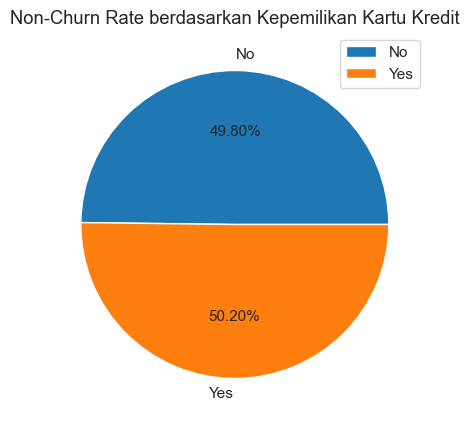

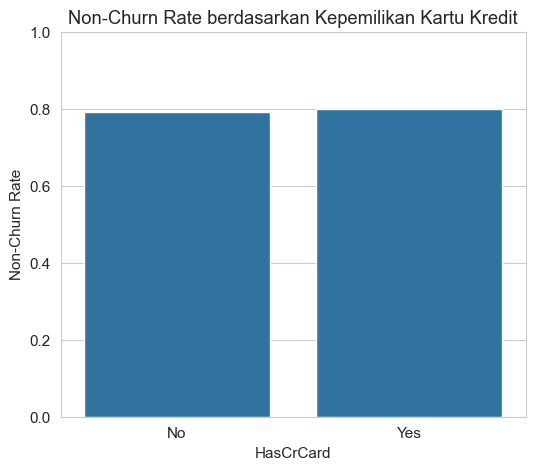

In [127]:
plt.figure(figsize=(6,5))

card_plot = card_summary.copy()
card_plot["HasCrCard"] = card_plot["HasCrCard"].map({0: "No", 1: "Yes"})

plt.pie(
    card_plot["NonChurn_Rate"],
    labels=card_plot["HasCrCard"],
    autopct="%1.2f%%"
)

plt.title("Non-Churn Rate berdasarkan Kepemilikan Kartu Kredit")
plt.legend(loc="best")

plt.show()

plt.figure(figsize=(6,5))

sns.barplot(
    data=card_plot,
    x="HasCrCard",
    y="NonChurn_Rate"
)

plt.ylabel("Non-Churn Rate")
plt.title("Non-Churn Rate berdasarkan Kepemilikan Kartu Kredit")
plt.ylim(0,1)

plt.show()

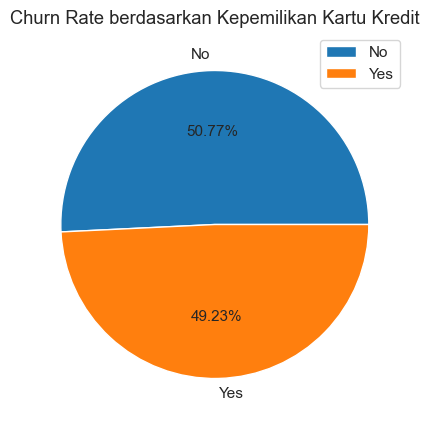

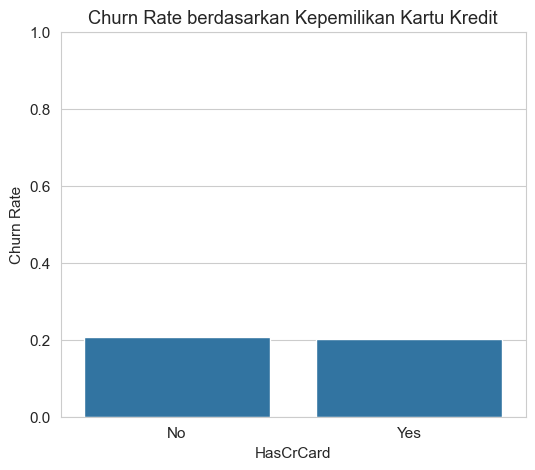

In [128]:
card_plot = card_summary.copy()

card_plot["HasCrCard"] = card_plot["HasCrCard"].map({
    0: "No",
    1: "Yes"
})

plt.figure(figsize=(6,5))

plt.pie(
    card_plot["Churn_Rate"],
    labels=card_plot["HasCrCard"],
    autopct="%1.2f%%"
)

plt.title("Churn Rate berdasarkan Kepemilikan Kartu Kredit")
plt.legend(loc="best")

plt.show()

plt.figure(figsize=(6,5))

card_plot = card_summary.copy()
card_plot["HasCrCard"] = card_plot["HasCrCard"].map({0: "No", 1: "Yes"})

sns.barplot(
    data=card_plot,
    x="HasCrCard",
    y="Churn_Rate"
)

plt.ylabel("Churn Rate")
plt.title("Churn Rate berdasarkan Kepemilikan Kartu Kredit")
plt.ylim(0,1)

plt.show()

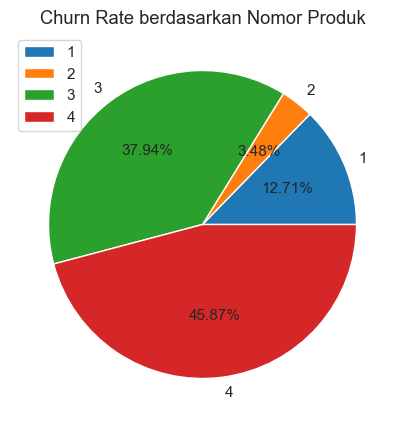

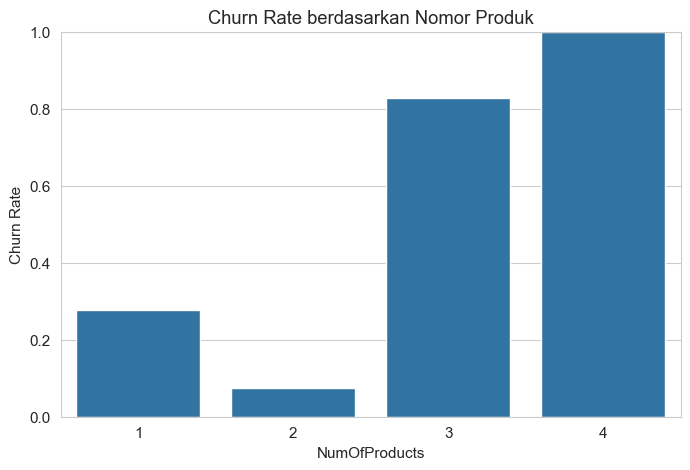

In [131]:
product_plot = product_summary.copy()

plt.figure(figsize=(8,5))

plt.pie(
    product_plot["Churn_Rate"],
    labels=product_plot["NumOfProducts"],
    autopct="%1.2f%%"
)

plt.title("Churn Rate berdasarkan Nomor Produk")
plt.legend(loc="best")

plt.show()

plt.figure(figsize=(8,5))

sns.barplot(
    data=product_plot,
    x="NumOfProducts",
    y="Churn_Rate"
)

plt.ylabel("Churn Rate")
plt.title("Churn Rate berdasarkan Nomor Produk")
plt.ylim(0,1)

plt.show()

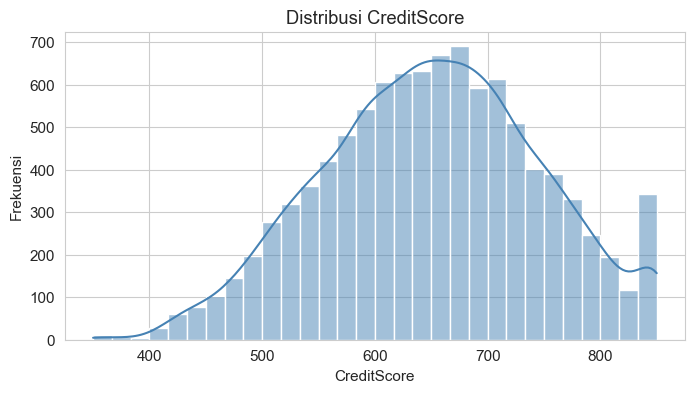

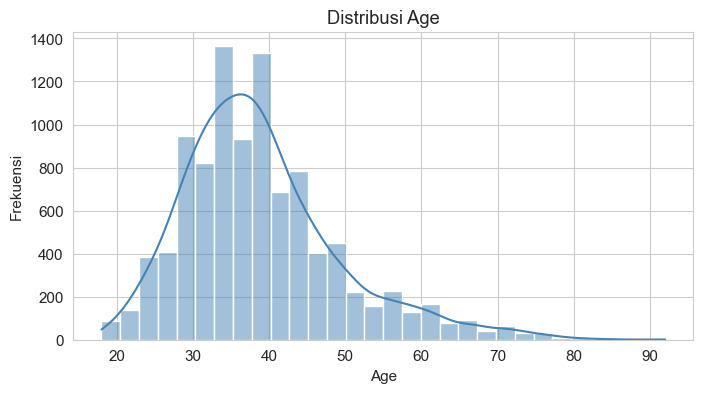

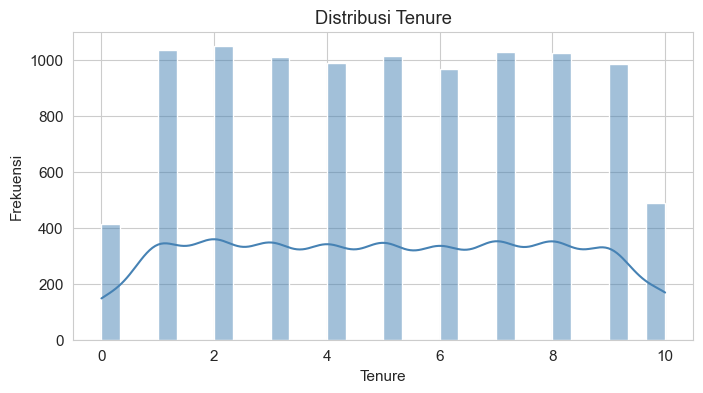

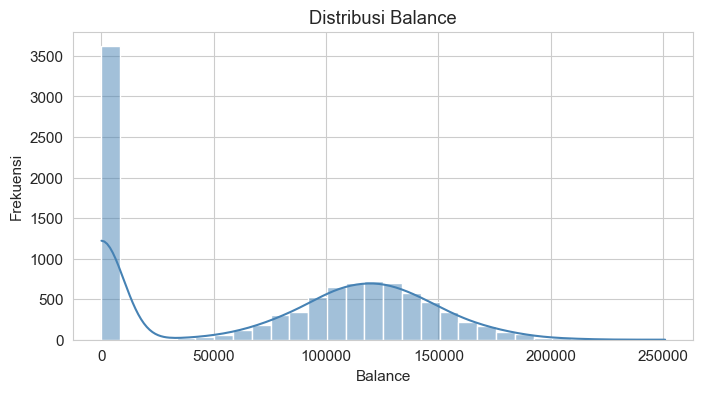

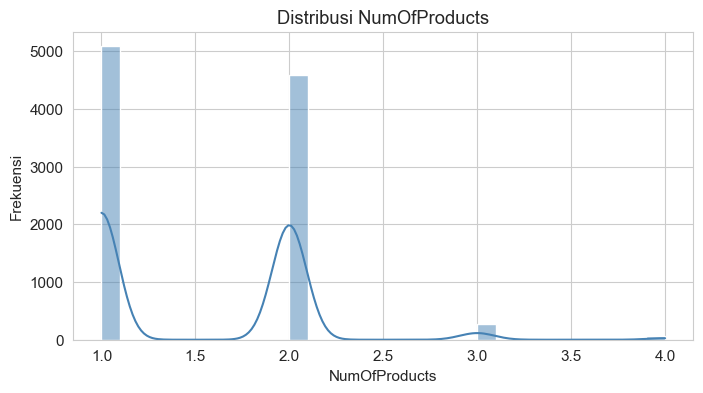

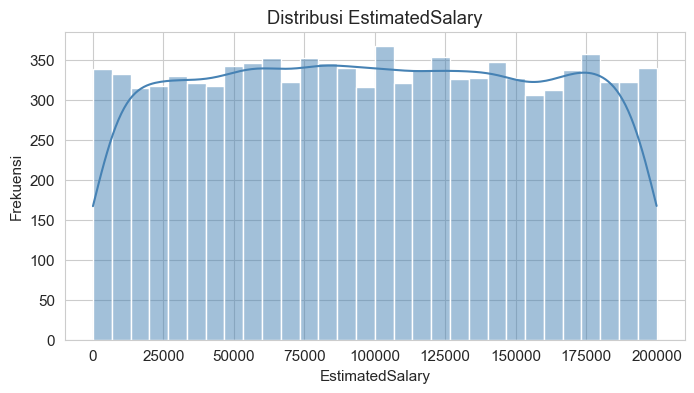

In [ ]:
# ==========================================================
# DISTRIBUSI FITUR NUMERIK
# ==========================================================

numerical_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]

for feature in numerical_features:

    plt.figure(figsize=(8,4))

    sns.histplot(
        data=df,
        x=feature,
        kde=True,
        bins=30,
        color="steelblue"
    )

    plt.title(f"Distribusi {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frekuensi")

    plt.show()

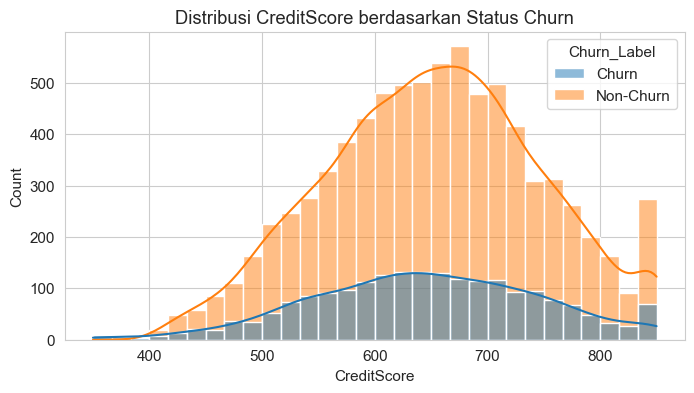

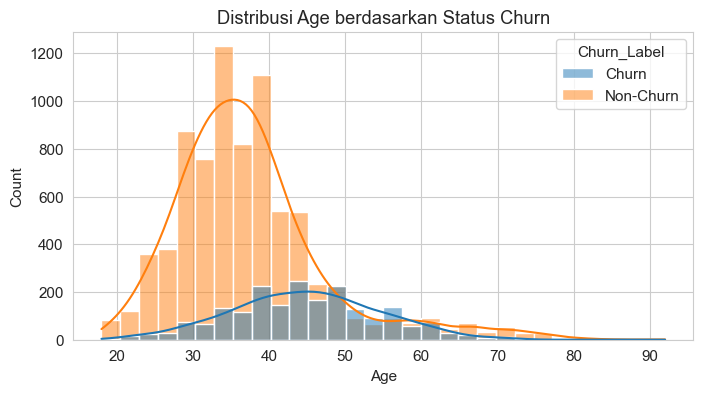

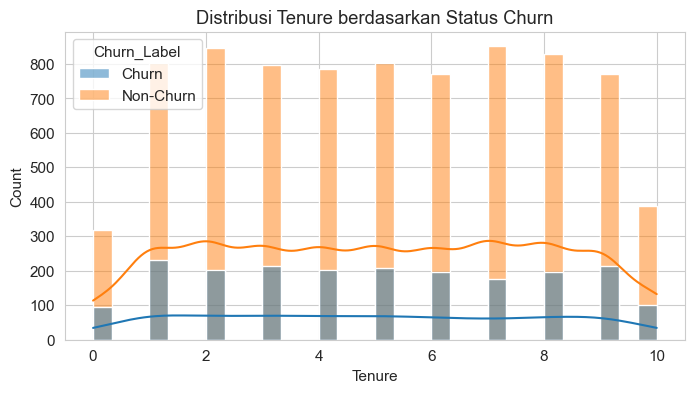

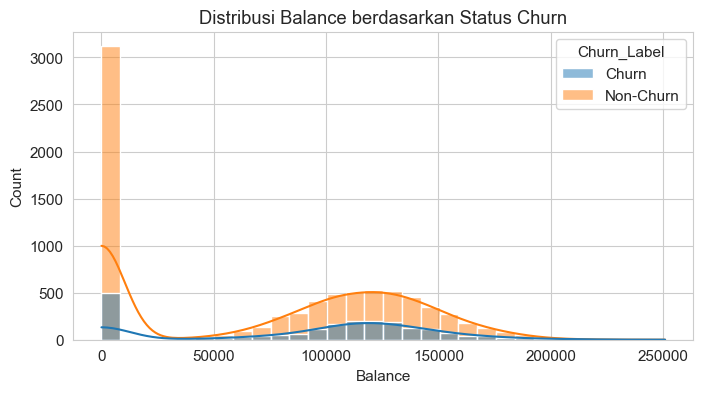

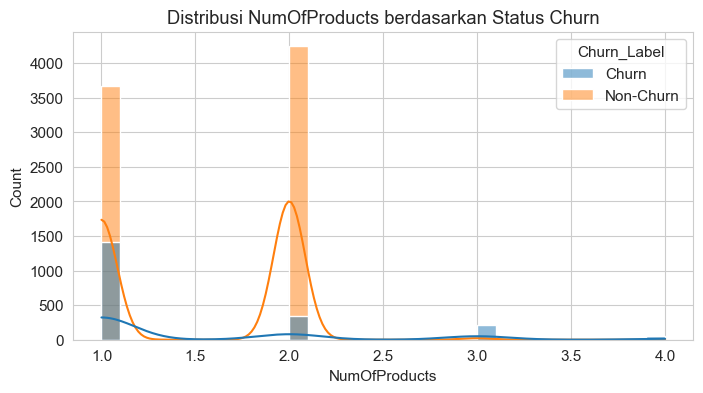

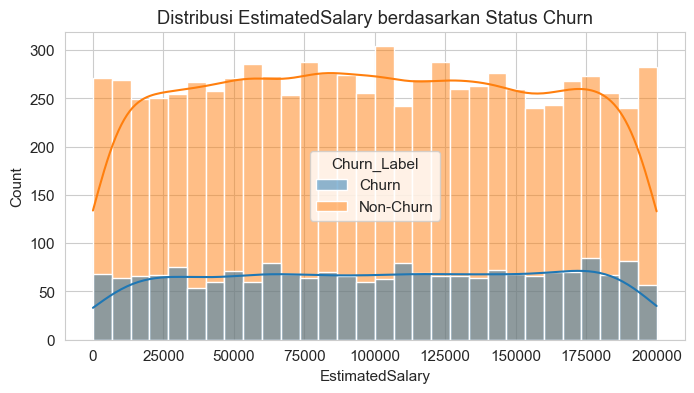

In [ ]:
# ==========================================================
# DISTRIBUSI BERDASARKAN STATUS CHURN
# ==========================================================

for feature in numerical_features:

    plt.figure(figsize=(8,4))

    sns.histplot(
        data=df,
        x=feature,
        hue="Churn_Label",
        kde=True,
        bins=30,
        multiple="layer"
    )

    plt.title(f"Distribusi {feature} berdasarkan Status Churn")

    plt.show()

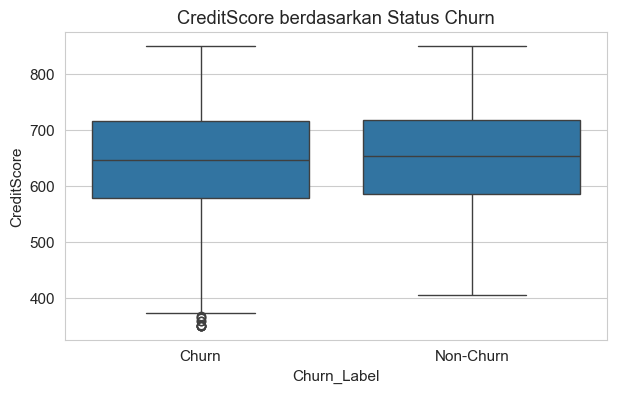

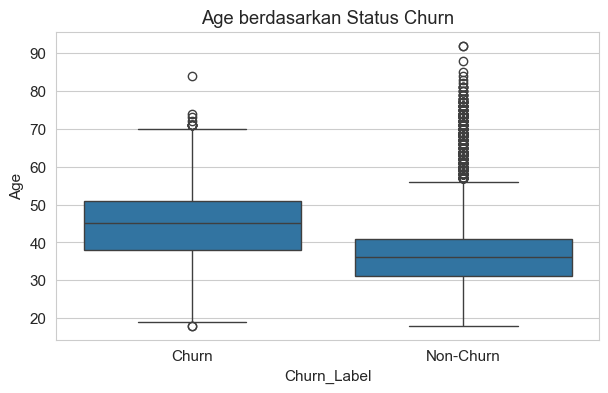

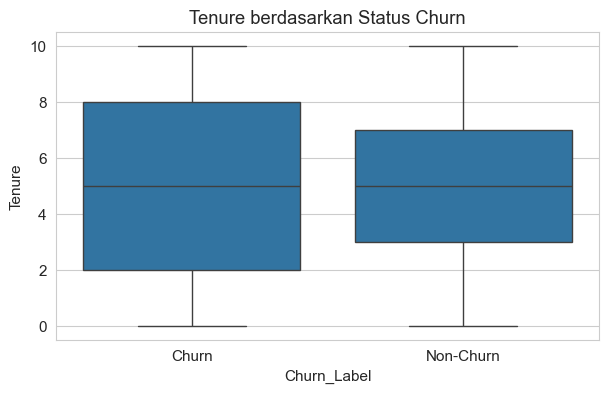

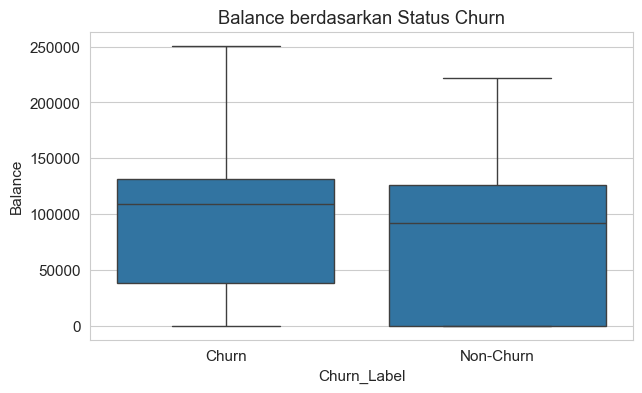

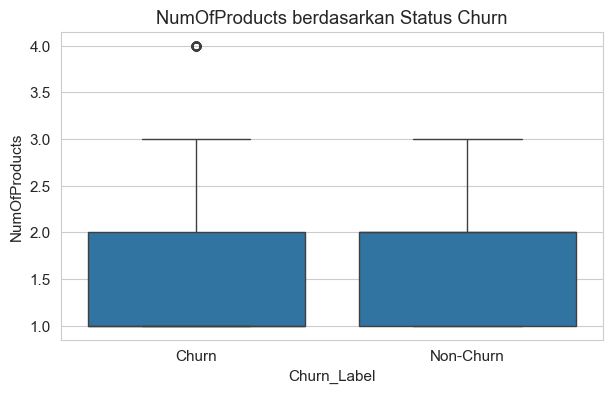

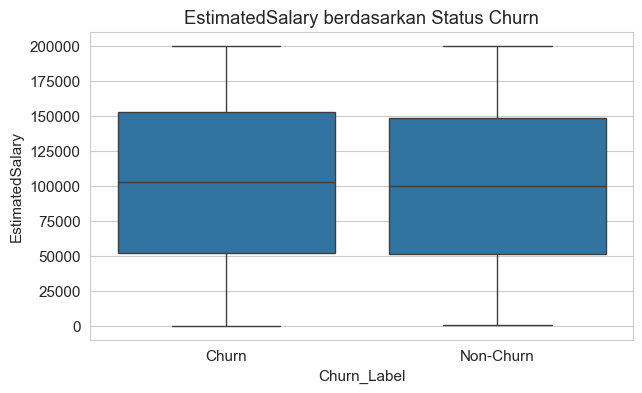

In [ ]:
# ==========================================================
# BOXPLOT BERDASARKAN STATUS CHURN
# ==========================================================

for feature in numerical_features:

    plt.figure(figsize=(7,4))

    sns.boxplot(
        data=df,
        x="Churn_Label",
        y=feature
    )

    plt.title(f"{feature} berdasarkan Status Churn")

    plt.show()

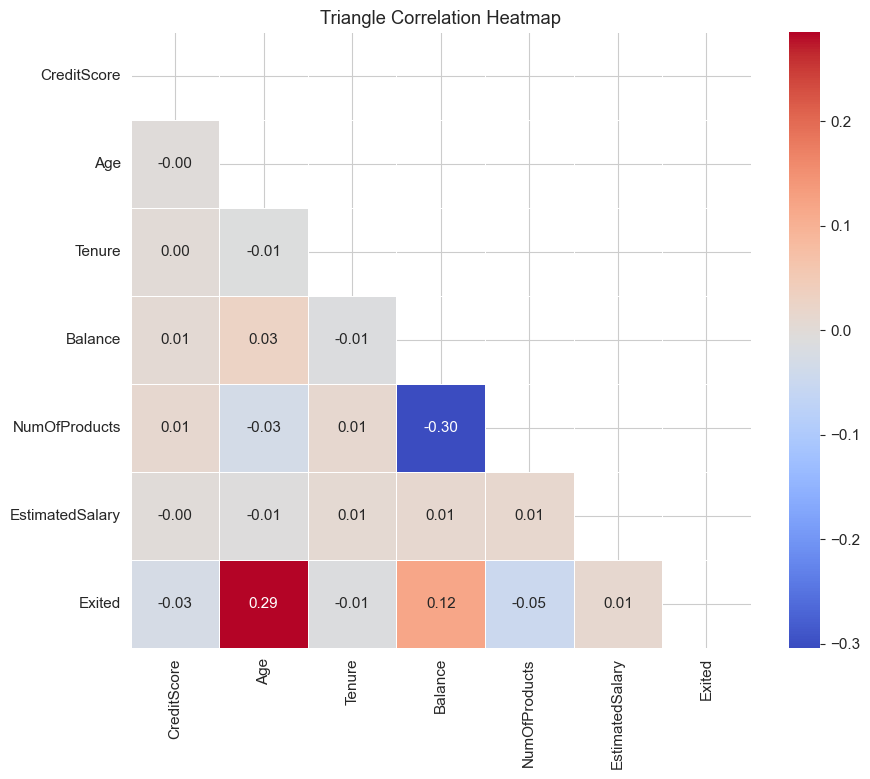

In [ ]:
# ==========================================================
# TRIANGLE CORRELATION HEATMAP
# ==========================================================

corr = df[
    numerical_features + ["Exited"]
].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Triangle Correlation Heatmap")
plt.show()